# Intro: Shortest Paths on OpenStreetMap

Efficient route planning is a fundamental problem in geospatial analysis, navigation systems, and logistics. This project utilizes **OpenStreetMap (OSM) data** to visualize maps and compute the shortest path between two locations using different algorithms.  

### Objectives:  
- Develop a **map visualization and route planning** tool using Python.  
- Implement and compare **two shortest path algorithms**: Dijkstra's Algorithm and the Two-Q Algorithm.  
- Generate interactive **KeplerGL-based visualizations** for an intuitive understanding of the computed routes.  
- Compare algorithm performances in terms of **execution time and route efficiency**.  

### Outline: 
1. Required Libraries and Data Loading 
    * Readings OSM Data 
    * Parse/clean the raw OSM data
2. Shortest Path Algortihm Two-Q and Dijkstra's
4. Algorithm Comparison 
5. Visualization with KeplerGL
6. Conclusion and Future Work
    * Strengths and weaknesses of the algorithms
    * Potential improvements and next steps  

## Data Preperation
    1 Importing necessary libraries 
    2 Loading OpenStreetMap (OSM) data 
    3 Explore, plot

In [1]:
#Required Libraries and Data Loading  
import pandas as pd
import geopandas as gpd
from shapely.geometry import LineString, Point
import osmnx as ox
import os
import time
import networkx as nx
import matplotlib.pyplot as plt
import scipy
import heapq
from tqdm import tqdm
from shapely.geometry import Point
import geopandas as gpd
import json

## Load OSM Data


In [3]:
#Parse OSM Munich center data with OSMNX library as graph 
muc_graph = ox.graph.graph_from_xml('../data/munich_center.osm', simplify=True, retain_all=False)

## Explore, plot

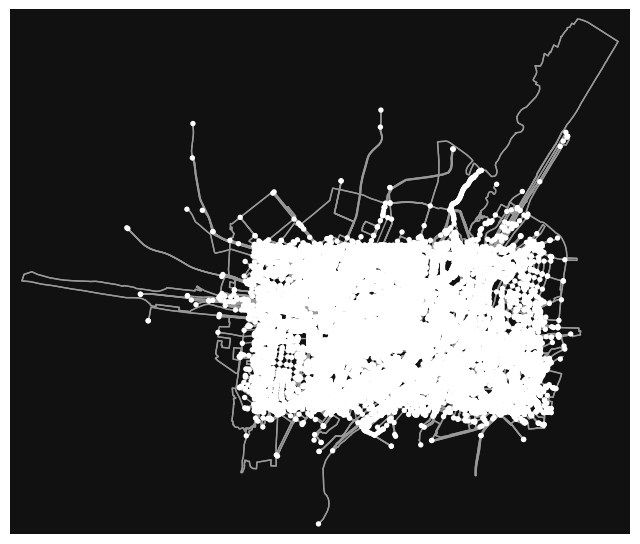

In [4]:
#Plot the streets 
fig, ax = ox.plot_graph(muc_graph) 

In [5]:
#Project the graph: re-project the graph from latitudes and longitudes to an appropriate UTM zone
muc_graph_proj = ox.project_graph(muc_graph)

## Extract Nodes and Edges

In [6]:
#Retrieve Edges and Nodes from the graph
edges = ox.graph_to_gdfs(muc_graph, nodes=False, edges=True)

#Check the data with Lat, long format
edges.head()

osmid    highway lanes  \
u      v          key                                                       
277381 1099934871 0                              4471065  secondary     2   
       775283935  0                            543004597  secondary     4   
       295209     0                            292767090  secondary     4   
277382 8678913443 0                             48919211  secondary     4   
       775283935  0    [543004595, 543004596, 543004597]  secondary     4   

                      maxspeed                 name  oneway reversed  \
u      v          key                                                  
277381 1099934871 0         50  Martin-Greif-Straße    True    False   
       775283935  0         50   Schwanthalerstraße   False     True   
       295209     0         50   Schwanthalerstraße   False    False   
277382 8678913443 0         30   Schwanthalerstraße   False     True   
       775283935  0         50   Schwanthalerstraße   False    False   

                           length  \
u      v          key               
277381 1099934871 0     13.594510   
       775283935  0      7.932756   
       295209     0     10.990510   
277382 8678913443 0     46.432784   
       775283935  0    126.170163   

                                                                geometry  \
u      v          key                                                      
277381 1099934871 0     LINESTRING (11.5498 48.13755, 11.54981 48.13767)   
       775283935  0     LINESTRING (11.5498 48.13755, 11.54991 48.13755)   
       295209     0    LINESTRING (11.5498 48.13755, 11.54974 48.1375...   
277382 8678913443 0    LINESTRING (11.55161 48.13754, 11.55223 48.13753)   
       775283935  0    LINESTRING (11.55161 48.13754, 11.55119 48.137...   

                      landuse access service  ref bridge area tunnel width  \
u      v          key                                                        
277381 1099934871 0       NaN    NaN     NaN  NaN    NaN  NaN    NaN   NaN   
       775283935  0       NaN    NaN     NaN  NaN    NaN  NaN    NaN   NaN   
       295209     0       NaN    NaN     NaN  NaN    NaN  NaN    NaN   NaN   
277382 8678913443 0       NaN    NaN     NaN  NaN    NaN  NaN    NaN   NaN   
       775283935  0       NaN    NaN     NaN  NaN    NaN  NaN    NaN   NaN   

                      junction est_width  
u      v          key                     
277381 1099934871 0        NaN       NaN  
       775283935  0        NaN       NaN  
       295209     0        NaN       NaN  
277382 8678913443 0        NaN       NaN  
       775283935  0        NaN       NaN

In [7]:
#Retrieve Edges and Nodes from the graph with corrected projection
nodes_proj, edges_proj = ox.graph_to_gdfs(muc_graph_proj, nodes=True, edges=True)

In [8]:
#Control coordinate system of edges 
edges_proj.crs

<Projected CRS: EPSG:32632>
Name: WGS 84 / UTM zone 32N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 6°E and 12°E, northern hemisphere between equator and 84°N, onshore and offshore. Algeria. Austria. Cameroon. Denmark. Equatorial Guinea. France. Gabon. Germany. Italy. Libya. Liechtenstein. Monaco. Netherlands. Niger. Nigeria. Norway. Sao Tome and Principe. Svalbard. Sweden. Switzerland. Tunisia. Vatican City State.
- bounds: (6.0, 0.0, 12.0, 84.0)
Coordinate Operation:
- name: UTM zone 32N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

# Shortest Path Algorithms

    1. Implement Two-Q
    2. Dijkstra's Algrotihm

## Setting Start and End Nodes 

/var/folders/_z/sc0jk_9x723gd8q1yqy_ts940000gn/T/ipykernel_10137/3633773078.py:2: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  convex_hull = edges_proj.unary_union.convex_hull


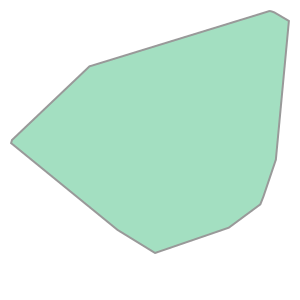

In [9]:
# Get the Convex Hull of the network
convex_hull = edges_proj.unary_union.convex_hull
# Show output
convex_hull

In [10]:
# Get the Convex Hull of the network
convex_hull = edges_proj.unary_union.convex_hull

# Centroid
centroid = convex_hull.centroid

# Show
print(centroid)

/var/folders/_z/sc0jk_9x723gd8q1yqy_ts940000gn/T/ipykernel_10137/1653990290.py:2: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  convex_hull = edges_proj.unary_union.convex_hull


POINT (691008.1945096496 5335856.458416031)


In [11]:
#Find the Origin and Target point

# Get the x coordinates of the nodes
nodes_proj['x'] = nodes_proj["x"].astype(float)

In [12]:
minn = nodes_proj['x'].min()

In [13]:
target = nodes_proj.loc[nodes_proj['x']==minn, 'geometry'].values[0]
print(target)

POINT (686896.0979297942 5336447.3376191715)


In [14]:
# Get origin x and y coordinates
orig_xy = (centroid.y, centroid.x)

# Get target x and y coordinates
target_xy = (target.y, target.x)

In [29]:
from osmnx import distance

# Find the node in the graph that is closest to the origin point (here, we want to get the node id)
orig_node = distance.nearest_nodes(muc_graph_proj, X=orig_xy[1], Y=orig_xy[0])
target_node = distance.nearest_nodes(muc_graph_proj, X=target_xy[1], Y=target_xy[0])

print("Origin node:", orig_node)
print("Target node:", target_node)



Origin node: 2349278103
Target node: 297265330


In [30]:
# Retrieve the rows from the nodes GeoDataFrame
o_closest = nodes_proj.loc[orig_node]
t_closest = nodes_proj.loc[target_node]

In [31]:
# Create a GeoDataFrame from the origin and target points
od_nodes = gpd.GeoDataFrame([o_closest, t_closest], geometry='geometry', crs=nodes_proj.crs)
od_nodes.head()

,y,x,highway,railway,ref,geometry
2349278103,5.335847e+06,691012.410044,NaN,NaN,NaN,POINT (691012.41 5335847.157)
297265330,5.336447e+06,686896.097930,NaN,NaN,NaN,POINT (686896.098 5336447.338)


## Two-Q Algorithm 

In [32]:
# Calculate the shortest path
def two_q_shortest_path(graph, start, end):
    """Finds the shortest path using the Two-Q algorithm."""
    Q1 = [(0, start, [])]  # (Cost, node, path)
    Q2 = []
    visited = set()

    while Q1 or Q2:
        if Q1:
            cost, current, path = heapq.heappop(Q1)
        else:
            cost, current, path = heapq.heappop(Q2)

        if current == end:
            return path + [current], cost

        if current in visited:
            continue
        visited.add(current)

        for neighbor, data in graph[current].items():
            if neighbor not in visited:
                new_cost = cost + data[0].get('length', 1)  # Use length as edge weight
                new_path = path + [current]
                if new_cost < 1000 : #Separating the queues based on a randomly selected cost value.
                    heapq.heappush(Q1, (new_cost, neighbor, new_path))
                else:
                    heapq.heappush(Q2, (new_cost, neighbor, new_path))
    return None, float('inf')  # Return infinity if no path is found

# Find the shortest path using the Two-Q algorithm
two_q_route, two_q_cost = two_q_shortest_path(muc_graph, orig_node, target_node)

if two_q_route:
    print("Two-Q Route:", two_q_route)
    print("Two-Q Cost:", two_q_cost)
else:
    print("No route found with Two-Q.")

Two-Q Route: [2349278103, 2349278105, 8748689408, 1907449212, 618702521, 967091779, 243358947, 654580328, 243358936, 243358935, 243358934, 243358933, 243358939, 243358927, 243358926, 223949205, 223951563, 8748885654, 8119191888, 2404001198, 3228070936, 3307332479, 1077566664, 3953206276, 8748885667, 1077566259, 246878845, 2844721423, 2844721429, 1362827596, 1840947345, 1362827597, 2830370656, 2830370616, 6806546197, 6975605714, 1011797584, 1077566600, 3017699265, 1077566595, 1077566562, 1077566167, 3017699266, 788021897, 774634208, 3463306447, 3463306451, 1106648595, 4464804310, 3573856577, 4464804302, 3393433210, 4464804391, 1077566483, 774634149, 1077566677, 1145362835, 2734171681, 2966573105, 2966573106, 2966573108, 774634127, 2734171704, 363192, 363191, 3809858759, 21632160, 4268520832, 3700240481, 818083375, 1659974517, 8266983462, 8266983461, 1659974455, 7002654723, 6209749146, 6209749147, 6209749148, 6209749141, 6071582320, 201416172, 2475788296, 6071582319, 737219006, 375711434

## Dijkstra's Algorithm  

In [33]:
def dijkstra_shortest_path(graph, start, end):
    """Finds the shortest path using Dijkstra's algorithm."""
    distances = {node: float('inf') for node in graph.nodes()}
    distances[start] = 0
    previous = {node: None for node in graph.nodes()}
    queue = [(0, start)]

    while queue:
        current_distance, current_node = heapq.heappop(queue)

        if current_distance > distances[current_node]:
            continue

        for neighbor, data in graph[current_node].items():
            distance = current_distance + data[0].get('length', 1)
            if distance < distances[neighbor]:
                distances[neighbor] = distance
                previous[neighbor] = current_node
                heapq.heappush(queue, (distance, neighbor))

    path = []
    current = end
    while current is not None:
        path.append(current)
        current = previous[current]
    path.reverse()

    return path, distances[end]

# Find the shortest path using Dijkstra's algorithm
dijkstra_route, dijkstra_cost = dijkstra_shortest_path(muc_graph, orig_node, target_node)

if dijkstra_route:
    print("Dijkstra Route:", dijkstra_route)
    print("Dijkstra Cost:", dijkstra_cost)
else:
    print("No route found with Dijkstra.")

Dijkstra Route: [2349278103, 2349278105, 8748689408, 1907449212, 618702521, 967091779, 243358947, 654580328, 243358936, 243358935, 243358934, 243358933, 243358939, 243358927, 243358926, 223949205, 223951563, 8748885654, 8119191888, 2404001198, 3228070936, 3307332479, 1077566664, 3953206276, 8748885667, 1077566259, 246878845, 2844721423, 2844721429, 1362827596, 1840947345, 1362827597, 2830370656, 2830370616, 6806546197, 6975605714, 1011797584, 1077566600, 3017699265, 1077566595, 1077566562, 1077566167, 3017699266, 788021897, 774634208, 3463306447, 3463306451, 1106648595, 4464804310, 3573856577, 4464804302, 3393433210, 4464804391, 1077566483, 774634149, 1077566677, 1145362835, 2734171681, 2966573105, 2966573106, 2966573108, 774634127, 2734171704, 363192, 363191, 3809858759, 21632160, 4268520832, 3700240481, 818083375, 1659974517, 8266983462, 8266983461, 1659974455, 7002654723, 6209749146, 6209749147, 6209749148, 6209749141, 6071582320, 201416172, 2475788296, 6071582319, 737219006, 375711

## Algorithm Comparison  

Performance analysis (execution time, number of nodes, etc.)

In [34]:
import time

# Measure the execution time of the Two-Q algorithm
start_time = time.time()
two_q_route, two_q_cost = two_q_shortest_path(muc_graph, orig_node, target_node)
two_q_time = time.time() - start_time

# Measure the execution time of Dijkstra's algorithm
start_time = time.time()
dijkstra_route, dijkstra_cost = dijkstra_shortest_path(muc_graph, orig_node, target_node)
dijkstra_time = time.time() - start_time

print(f"Two-Q Execution Time: {two_q_time} s")
print(f"Dijkstra Execution Time: {dijkstra_time} s")

# Compare route lengths
if two_q_route and dijkstra_route:
    print(f"Two-Q Route Length: {two_q_cost} meters")
    print(f"Dijkstra Route Length: {dijkstra_cost} meters")

    # Walking speed calculation (average 5 km/hr)
    average_walking_speed = 5  # km/saat

    two_q_time_hours = (two_q_cost / 1000) / average_walking_speed  
    dijkstra_time_hours = (dijkstra_cost / 1000) / average_walking_speed 

    print(f"Two-Q Estimated Walking Time: {two_q_time_hours} hours")
    print(f"Dijkstra Estimated Walking Time: {dijkstra_time_hours} hours")
else:
    print("Comparison not possible as routes were not found.")

Two-Q Execution Time: 0.14738202095031738 s
Dijkstra Execution Time: 0.14155912399291992 s
Two-Q Route Length: 4845.111507390266 meters
Dijkstra Route Length: 4845.111507390266 meters
Two-Q Estimated Walking Time: 0.9690223014780532 hours
Dijkstra Estimated Walking Time: 0.9690223014780532 hours


In [35]:
if two_q_cost < dijkstra_cost:
    winner_algorithm = "Two-Q"
elif dijkstra_cost < two_q_cost:
    winner_algorithm = "Dijkstra"
else:
    winner_algorithm = "Tied"

print(f"Winner is: {winner_algorithm}")

Winner is: Tied


# Visaulization
    1. Displaying routes on an interactive map using KeplerGL  
    2. How to view and share the generated HTML output  

In [36]:
%%capture
!pip install folium
!pip install geopandas shapely

In [40]:
import folium
from folium.plugins import DualMap
import osmnx as ox

# Munich center coordinates and zoom level
munich_center = [48.14355889, 11.545238090]
zoom_level = 12.5

# Create the DualMap
m = DualMap(location=munich_center, zoom_start=zoom_level, tiles='cartodbpositron')

# HTML for the title and legend (bottom right corner, smaller box)
title_html = """
     <div align="left" style="position: fixed;
     bottom: 50px; right: 50px; width: 150px; height: 60px;
     border:2px solid grey; font-size:11px; z-index:9999; background-color:white;opacity:0.9; padding: 2px;">
       <h4 style="margin-top:2px; margin-bottom: 1.6px;">Routes</h4>
       <p style="margin-bottom: 2px;"><span style="color: red;">&#11044;</span> Two-Q algorithm</p>
       <p style="margin-bottom: 2px;"><span style="color: blue;">&#11044;</span> Dijkstra algorithm</p>
     </div>
     """

m.get_root().html.add_child(folium.Element(title_html))

# Add the Two-Q route to the first map
if two_q_route:
    two_q_coords = [(muc_graph.nodes[node]['y'], muc_graph.nodes[node]['x']) for node in two_q_route]
    folium.PolyLine(two_q_coords, color="red", weight=5, opacity=0.7, name="Two-Q Route").add_to(m.m1)
if orig_node in muc_graph.nodes:
    orig_point_two_q = [muc_graph.nodes[orig_node]['y'], muc_graph.nodes[orig_node]['x']]
    folium.Marker(orig_point_two_q, popup="Origin", icon=folium.Icon(color="green", icon="play")).add_to(m.m1)
if target_node in muc_graph.nodes:
    target_point_two_q = [muc_graph.nodes[target_node]['y'], muc_graph.nodes[target_node]['x']]
    folium.Marker(target_point_two_q, popup="Target", icon=folium.Icon(color="purple", icon="stop")).add_to(m.m1)

# Add the Dijkstra route to the second map
if dijkstra_route:
    dijkstra_coords = [(muc_graph.nodes[node]['y'], muc_graph.nodes[node]['x']) for node in dijkstra_route]
    folium.PolyLine(dijkstra_coords, color="blue", weight=5, opacity=0.7, name="Dijkstra Route").add_to(m.m2)
if orig_node in muc_graph.nodes:
    orig_point_dijkstra = [muc_graph.nodes[orig_node]['y'], muc_graph.nodes[orig_node]['x']]
    folium.Marker(orig_point_dijkstra, popup="Origin", icon=folium.Icon(color="green", icon="play")).add_to(m.m2)
if target_node in muc_graph.nodes:
    target_point_dijkstra = [muc_graph.nodes[target_node]['y'], muc_graph.nodes[target_node]['x']]
    folium.Marker(target_point_dijkstra, popup="Target", icon=folium.Icon(color="purple", icon="stop")).add_to(m.m2)

# Display the map
m.save("../outputs/dual_map_folium.html")
m

# Conclusion and Future Work  

In conclusion, this notebook presents a comparative visualization of different shortest path algorithms. You can access the full project code and other resources on the [GitHub Repository](https://github.com/oztuncbilek/shortest-path-osm).

* **Integrate Google Maps Live Traffic API:** Enhance the route planning functionality by integrating the Google Maps Live Traffic API.
* **Manual Start and End Point Selection :** EImplement a feature that allows users to manually select start and end points on the map. This will provide more flexibility and control over the route planning process, enabling users to customize their routes based on specific needs or preferences.
* **Load New OSM Data Dynamically:** Add functionality to load new OpenStreetMap (OSM) data dynamically.

